# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

David Santiago Rodríguez Ruiz

In [55]:
import pandas as pd

df = pd.read_csv('athlete_events.csv')

print("Dimensiones:", df.shape)
df.info()

Dimensiones: (271116, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [56]:
df.nunique().sort_values()

Sex            2
Season         2
Medal          3
Year          35
City          42
Games         51
Sport         66
Age           74
Height        95
Weight       220
NOC          230
Event        765
Team        1184
Name      134732
ID        135571
dtype: int64

In [57]:
columnas_descartar = ['ID', 'Name', 'Games', 'City', 'Team', 'Event']
df = df.drop(columns=columnas_descartar)
print("Columnas restantes:", df.columns.tolist())

Columnas restantes: ['Sex', 'Age', 'Height', 'Weight', 'NOC', 'Year', 'Season', 'Sport', 'Medal']


In [58]:
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df = df.dropna(subset=['Weight']).copy()
df['Medal'] = df['Medal'].fillna('No medal')

print("Duplicados encontrados:", df.duplicated().sum())
df = df.drop_duplicates().copy()

print("Nulos restantes:\n", df.isna().sum())
print("Dimensiones finales:", df.shape)

Duplicados encontrados: 52982
Nulos restantes:
 Sex          0
Age        707
Height    1311
Weight       0
NOC          0
Year         0
Season       0
Sport        0
Medal        0
dtype: int64
Dimensiones finales: (155259, 9)


Decidí descartar ID porque identifica los registros y Name porque identifica a los atletas, por lo que no son características adecuadas para predecir Weight. También eliminé Games, City y Team porque son variables redundantes o de alta cardinalidad para este modelo, y Event porque es una descripción muy granular del deporte. Medal se conserva en el dataframe para documentar su tratamiento, pero no se usa como predictor porque se conoce después de la competencia y podría generar filtración de información.

Para la limpieza, convertí Weight a numérico y eliminé los registros sin valor en la variable objetivo. Los duplicados se eliminaron después de imputar Medal, reemplazando sus valores faltantes por No medal. Los valores faltantes de Age y Height no se imputan antes de separar los datos: se completarán dentro del pipeline usando únicamente el conjunto de entrenamiento.

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [59]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

for c in cat_cols:
    print(f"{c}: {df[c].nunique()} categorías")

['Sex', 'NOC', 'Season', 'Sport', 'Medal']
Sex: 2 categorías
NOC: 226 categorías
Season: 2 categorías
Sport: 56 categorías
Medal: 4 categorías


Variables nominales:

Sex y Season son variables binarias sin orden. NOC y Sport son variables nominales sin jerarquía natural. Event también sería nominal, pero fue descartada por su alta cardinalidad y granularidad.

Variable ordinal:

Medal tiene un orden natural de desempeño: No medal < Bronze < Silver < Gold. Sin embargo, se descarta como predictora porque su valor se conoce después de la competencia y podría generar filtración de información.

Procesamiento recomendado:

- Sex y Season: One-Hot Encoding.
- Sport: One-Hot Encoding; sus categorías poco frecuentes podrían agruparse.
- NOC: One-Hot Encoding con agrupación de categorías infrecuentes o target encoding aplicado solo sobre entrenamiento.
- Medal: codificación ordinal únicamente si el objetivo fuera usarla y no existiera riesgo de filtración.

In [60]:
print("Sex:", df['Sex'].unique())
print("Season:", df['Season'].unique())
print("Medal:", df['Medal'].unique())
print()
print("NOC - categorías menos frecuentes (posibles atípicas):")
print(df['NOC'].value_counts().tail(10))
print()
print("Sport - categorías menos frecuentes:")
print(df['Sport'].value_counts().tail(5))

Sex: ['M' 'F']
Season: ['Summer' 'Winter']
Medal: ['No medal' 'Bronze' 'Gold' 'Silver']

NOC - categorías menos frecuentes (posibles atípicas):
NOC
BRU    9
YAR    9
ANZ    9
KOS    8
TUV    6
TLS    6
YMD    3
SSD    3
SAA    2
NFL    1
Name: count, dtype: int64

Sport - categorías menos frecuentes:
Sport
Tug-Of-War          52
Rugby               29
Art Competitions    17
Lacrosse             7
Motorboating         1
Name: count, dtype: int64


Variables con alta cardinalidad:

Entre las variables categóricas conservadas, NOC tiene alta cardinalidad, con muchos códigos de países y comités. Sport tiene una cardinalidad moderada. Event tenía aún más categorías, pero fue descartada antes del modelado por su alta granularidad y redundancia parcial con Sport.

Variables con categorías atípicas:

NOC contiene códigos de países o comités históricos con muy pocos registros. Sport contiene categorías extremadamente raras, como Motorboating, que aparece en muy pocos registros.

Procesamiento:

NOC puede codificarse con One-Hot Encoding agrupando categorías infrecuentes. Sport puede codificarse con One-Hot Encoding y, si fuera necesario, agrupar categorías poco frecuentes.

In [61]:
print("La variable Event fue descartada por su alta cardinalidad y granularidad.")
print("Cardinalidad de Sport:", df['Sport'].nunique())
print("Cardinalidad de NOC:", df['NOC'].nunique())

La variable Event fue descartada por su alta cardinalidad y granularidad.
Cardinalidad de Sport: 56
Cardinalidad de NOC: 226


Event: decidí descartarla porque tiene muchas categorías y sería complicado procesarla. Además, considero que gran parte de la información que contiene ya está representada en Sport, por lo que no aporta suficiente información adicional para el modelo.


Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

In [62]:
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

variables_numericas = ['Age', 'Height', 'Weight']

df[variables_numericas].describe()

,Age,Height,Weight
count,154552.000000,153948.000000,155259.000000
mean,25.474028,176.499877,72.304614
std,5.424817,10.379000,14.721044
min,11.000000,127.000000,25.000000
25%,22.000000,170.000000,62.000000
50%,25.000000,176.000000,71.000000
75%,28.000000,183.000000,81.000000
max,71.000000,226.000000,214.000000


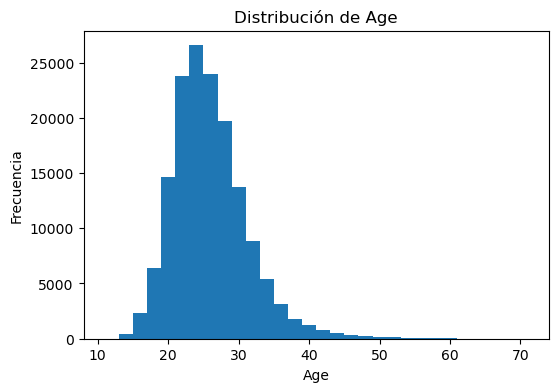

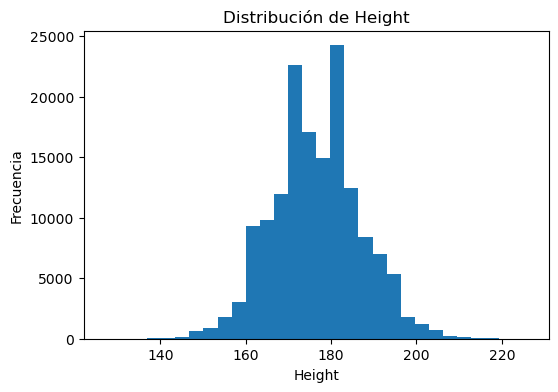

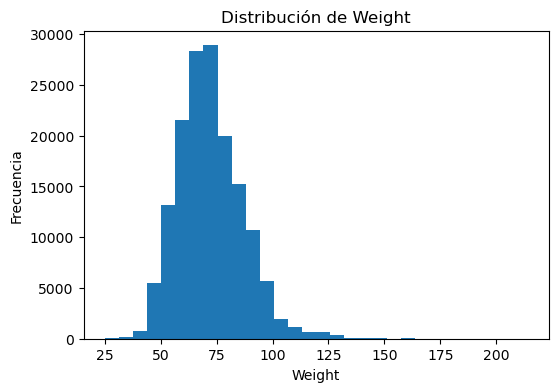

In [63]:
import matplotlib.pyplot as plt

for col in variables_numericas:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

In [64]:
print("Asimetría de las variables:")
print(df[variables_numericas].skew())

Asimetría de las variables:
Age       1.180574
Height    0.070573
Weight    0.845445
dtype: float64


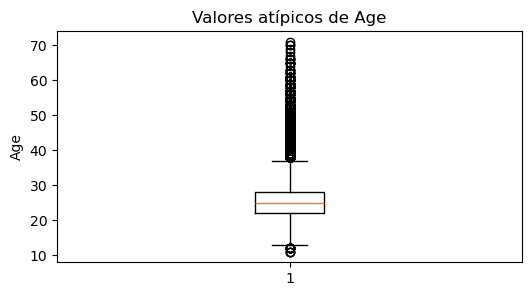

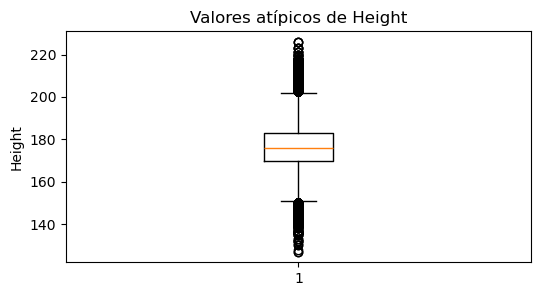

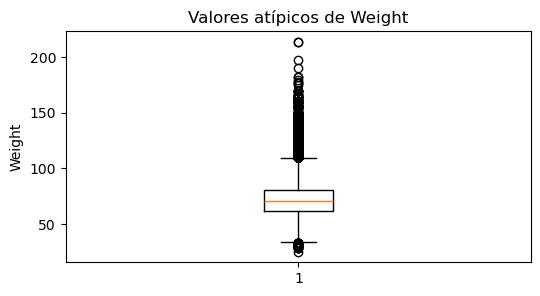

In [65]:
for col in variables_numericas:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col].dropna())
    plt.title(f'Valores atípicos de {col}')
    plt.ylabel(col)
    plt.show()

Las variables cuantitativas analizadas fueron Age, Height y Weight. Height presenta una distribución aproximadamente unimodal y cercana a la normal, mientras que Age y Weight muestran mayor asimetría. Los boxplots permiten observar valores atípicos en las tres variables.

Para el modelo, Age y Height se imputarán con la mediana calculada únicamente en el conjunto de entrenamiento y después se estandarizarán dentro del pipeline. Weight es la variable objetivo, por lo que no se transforma como característica; solo se eliminan sus registros faltantes.

## Análisis bivariado

Haga análisis bivariados entre las variables del dataset y la variable objetivo, e identifique qué variables serían potencialmente buenas predictoras y cuáles no.

Reporte sus resultados en una celda de texto.

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

variables_numericas = ['Age', 'Height', 'Weight']
correlacion = df[variables_numericas].corr()['Weight'].sort_values(ascending=False)

print("Correlación con Weight:")
print(correlacion)

Correlación con Weight:
Weight    1.000000
Height    0.775350
Age       0.164456
Name: Weight, dtype: float64


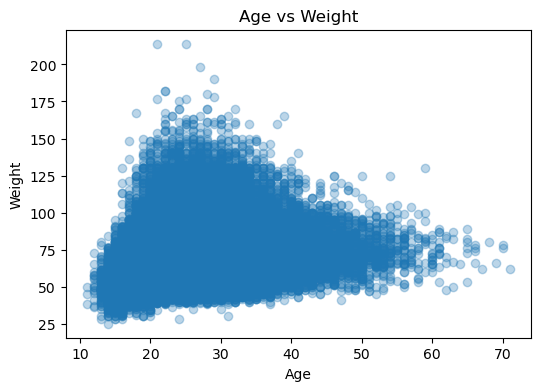

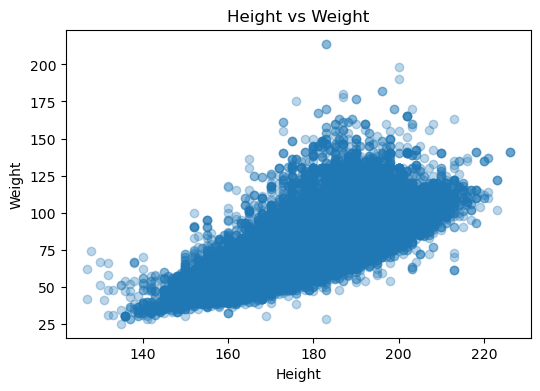

In [67]:
for col in ['Age', 'Height']:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df['Weight'], alpha=0.3)
    plt.xlabel(col)
    plt.ylabel('Weight')
    plt.title(f'{col} vs Weight')
    plt.show()

In [68]:
variables_categoricas = [
    'Sex', 'Season', 'Sport', 'NOC'
]

for col in variables_categoricas:
    print(f"\nPromedio de Weight según {col}:")
    print(df.groupby(col)['Weight'].mean().sort_values(ascending=False).head(10))


Promedio de Weight según Sex:
Sex
M    77.035455
F    61.499566
Name: Weight, dtype: float64

Promedio de Weight según Season:
Season
Summer    72.346003
Winter    72.088453
Name: Weight, dtype: float64

Promedio de Weight según Sport:
Sport
Tug-Of-War          95.615385
Bobsleigh           88.979609
Basketball          85.767131
Baseball            85.710808
Water Polo          84.567488
Handball            81.495793
Ice Hockey          80.812857
Rowing              80.101452
Beach Volleyball    79.089219
Volleyball          78.913043
Name: Weight, dtype: float64

Promedio de Weight según NOC:
NOC
NRU    95.846154
ASA    87.958333
SCG    84.984906
MNE    84.722222
CRO    84.109034
TGA    82.697674
ISL    81.907216
SRB    81.171171
SAM    80.989796
LAT    80.302083
Name: Weight, dtype: float64


<Figure size 600x400 with 0 Axes>

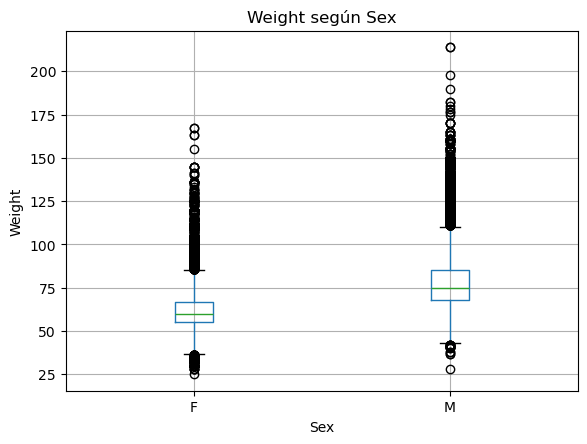

<Figure size 600x400 with 0 Axes>

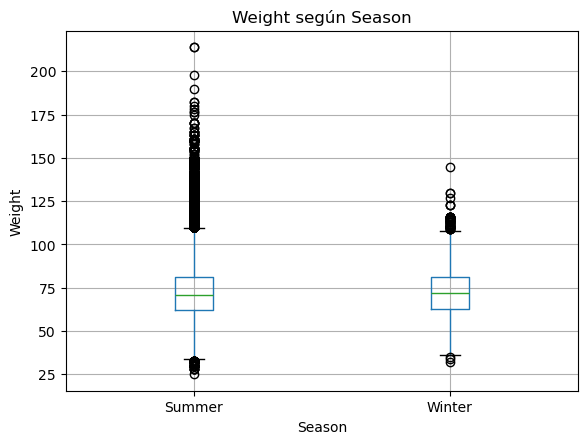

In [69]:
for col in ['Sex', 'Season']:
    plt.figure(figsize=(6,4))
    df.boxplot(column='Weight', by=col)
    plt.title(f'Weight según {col}')
    plt.suptitle('')
    plt.xlabel(col)
    plt.ylabel('Weight')
    plt.show()

En el análisis bivariado, Height presenta una correlación positiva fuerte con Weight, aproximadamente 0.78, por lo que es la principal variable predictora entre las cuantitativas analizadas. Age presenta una relación positiva débil, aproximadamente 0.16, por lo que puede aportar información adicional, aunque su capacidad predictiva es menor.

Entre las variables categóricas, Sex muestra diferencias importantes en el peso promedio entre hombres y mujeres. Sport también presenta diferencias entre categorías y puede ser útil como predictor. Season muestra diferencias pequeñas, mientras que NOC puede aportar información, aunque su alta cardinalidad aumenta la complejidad del procesamiento.

Por tanto, Height, Sex y Sport son buenas candidatas para el modelo. Age y Year pueden aportar información complementaria. Medal no se utiliza como predictor porque se conoce después de la competencia y podría producir fuga de información.

## Procesamiento de las características y entrenamiento del modelo

Cree la matriz de características X con todas las variables no descartadas del dataframe, menos Weight, que será la variable objetivo y.

Particione los datos en subconjuntos de entrenamiento y prueba, en una relación 80/20, usando random_state=1.

Para la primera versión se seleccionan cinco características: Height, Age, Year, Sex y Sport. Year se considera una característica temporal ordenada y se estandariza; Sex y Sport son nominales y se codifican con One-Hot Encoding.

Las transformaciones se empaquetan con ColumnTransformer y remainder='drop'. Como Weight es una variable numérica, el modelo técnicamente correcto es LinearRegression, aunque la consigna mencione regresión logística. La regresión logística se utiliza para clasificación, no para predecir pesos continuos.

Entrene el modelo, reporte los scores de entrenamiento y prueba y muestre las características resultantes del procesamiento.

In [70]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Weight'])
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=1
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (124207, 8)
X_test: (31052, 8)
y_train: (124207,)
y_test: (31052,)


In [71]:
caracteristicas = ['Height', 'Age', 'Year', 'Sex', 'Sport']

X_train_modelo = X_train[caracteristicas]
X_test_modelo = X_test[caracteristicas]

In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numericas = ['Height', 'Age']
temporal = ['Year']
nominales = ['Sex', 'Sport']

procesamiento_numerico = Pipeline([
    ('imputacion', SimpleImputer(strategy='median')),
    ('escalado', StandardScaler())
])

preprocesamiento = ColumnTransformer(
    transformers=[
        ('num', procesamiento_numerico, numericas),
        ('temporal', StandardScaler(), temporal),
        ('cat', OneHotEncoder(handle_unknown='ignore'), nominales)
    ],
    remainder='drop'
)

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

modelo = Pipeline([
    ('preprocesamiento', preprocesamiento),
    ('modelo', LinearRegression())
])

modelo.fit(X_train_modelo, y_train)

print("Score entrenamiento:", modelo.score(X_train_modelo, y_train))
print("Score prueba:", modelo.score(X_test_modelo, y_test))

Score entrenamiento: 0.6952169439906368
Score prueba: 0.6869207410600358


In [74]:
caracteristicas_reales = modelo.named_steps['preprocesamiento'].get_feature_names_out()

print("Características con las que realmente se entrenó el modelo:")
for caracteristica in caracteristicas_reales:
    print(caracteristica)

Características con las que realmente se entrenó el modelo:
num__Height
num__Age
temporal__Year
cat__Sex_F
cat__Sex_M
cat__Sport_Alpine Skiing
cat__Sport_Archery
cat__Sport_Art Competitions
cat__Sport_Athletics
cat__Sport_Badminton
cat__Sport_Baseball
cat__Sport_Basketball
cat__Sport_Beach Volleyball
cat__Sport_Biathlon
cat__Sport_Bobsleigh
cat__Sport_Boxing
cat__Sport_Canoeing
cat__Sport_Cross Country Skiing
cat__Sport_Curling
cat__Sport_Cycling
cat__Sport_Diving
cat__Sport_Equestrianism
cat__Sport_Fencing
cat__Sport_Figure Skating
cat__Sport_Football
cat__Sport_Freestyle Skiing
cat__Sport_Golf
cat__Sport_Gymnastics
cat__Sport_Handball
cat__Sport_Hockey
cat__Sport_Ice Hockey
cat__Sport_Judo
cat__Sport_Lacrosse
cat__Sport_Luge
cat__Sport_Modern Pentathlon
cat__Sport_Motorboating
cat__Sport_Nordic Combined
cat__Sport_Rhythmic Gymnastics
cat__Sport_Rowing
cat__Sport_Rugby
cat__Sport_Rugby Sevens
cat__Sport_Sailing
cat__Sport_Shooting
cat__Sport_Short Track Speed Skating
cat__Sport_Skelet

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [75]:
caracteristicas_7 = [
    'Height',
    'Age',
    'Year',
    'Sex',
    'Sport',
    'Season',
    'NOC'
]

X_train_modelo = X_train[caracteristicas_7]
X_test_modelo = X_test[caracteristicas_7]

In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numericas = ['Height', 'Age']
temporal = ['Year']
nominales = ['Sex', 'Sport', 'Season', 'NOC']

procesamiento_numerico = Pipeline([
    ('imputacion', SimpleImputer(strategy='median')),
    ('escalado', StandardScaler())
])

preprocesamiento_7 = ColumnTransformer(
    transformers=[
        ('num', procesamiento_numerico, numericas),
        ('temporal', StandardScaler(), temporal),
        ('cat', OneHotEncoder(handle_unknown='ignore'), nominales)
    ],
    remainder='drop'
)

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

modelo_7 = Pipeline([
    ('preprocesamiento', preprocesamiento_7),
    ('modelo', LinearRegression())
])

modelo_7.fit(X_train_modelo, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  ['Height', 'Age']),
                                                 ('temporal', StandardScaler(),
                                                  ['Year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Sport', 'Season',
                                                   'NOC'])])),
                ('modelo', LinearRegression())])

In [78]:
print("Score de entrenamiento:", modelo_7.score(X_train_modelo, y_train))
print("Score de prueba:", modelo_7.score(X_test_modelo, y_test))

Score de entrenamiento: 0.7013203410998554
Score de prueba: 0.6926709772646135


In [79]:
caracteristicas_reales = (
    modelo_7
    .named_steps['preprocesamiento']
    .get_feature_names_out()
)

print("Características reales con las que fue entrenado el modelo:")

for caracteristica in caracteristicas_reales:
    print(caracteristica)

Características reales con las que fue entrenado el modelo:
num__Height
num__Age
temporal__Year
cat__Sex_F
cat__Sex_M
cat__Sport_Alpine Skiing
cat__Sport_Archery
cat__Sport_Art Competitions
cat__Sport_Athletics
cat__Sport_Badminton
cat__Sport_Baseball
cat__Sport_Basketball
cat__Sport_Beach Volleyball
cat__Sport_Biathlon
cat__Sport_Bobsleigh
cat__Sport_Boxing
cat__Sport_Canoeing
cat__Sport_Cross Country Skiing
cat__Sport_Curling
cat__Sport_Cycling
cat__Sport_Diving
cat__Sport_Equestrianism
cat__Sport_Fencing
cat__Sport_Figure Skating
cat__Sport_Football
cat__Sport_Freestyle Skiing
cat__Sport_Golf
cat__Sport_Gymnastics
cat__Sport_Handball
cat__Sport_Hockey
cat__Sport_Ice Hockey
cat__Sport_Judo
cat__Sport_Lacrosse
cat__Sport_Luge
cat__Sport_Modern Pentathlon
cat__Sport_Motorboating
cat__Sport_Nordic Combined
cat__Sport_Rhythmic Gymnastics
cat__Sport_Rowing
cat__Sport_Rugby
cat__Sport_Rugby Sevens
cat__Sport_Sailing
cat__Sport_Shooting
cat__Sport_Short Track Speed Skating
cat__Sport_Skelet

Para esta parte volví a entrenar el modelo agregando dos características más a las cinco que había utilizado anteriormente, quedando con un total de siete características. Al hacer el procesamiento, las variables categóricas se transformaron con One-Hot Encoding, por lo que al final el modelo trabajó con más columnas de las siete que seleccioné inicialmente. Finalmente, comparé los scores de entrenamiento y de prueba con los del modelo anterior para revisar si agregar estas dos características ayudó a mejorar el resultado.
